# Лабораторна робота №3
## Тема: Лінійна регресія у Scikit-learn: підготовка даних, навчання, прогнозування та оцінювання якості моделі

**Студент:** Адамчук Ярослав  
**Група:** МІТ 31  
**Номер у списку (seed / random_state):** 2  

### Інформація про набір даних:
* **Назва:** Auto MPG Data Set
* **Джерело:** UCI Machine Learning Repository (Carnegie Mellon University StatLib)
* **Ліцензія:** Open Data / CC BY 4.0
* **Цільова змінна ($y$):** `mpg` — паливна ефективність (миль на галон пального, miles per gallon).
* **Задача прогнозування:** Спрогнозувати паливну економічність автомобіля (`mpg`) на основі його технічних характеристик (вага, потужність, об'єм двигуна тощо).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Фіксація seed згідно з номером студента у списку групи
seed = 2
print("Бібліотеки успішно завантажено. Random seed =", seed)

Бібліотеки успішно завантажено. Random seed = 2


In [2]:
# Пряме завантаження датасету з репозиторію
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
column_names = [
    "mpg", "cylinders", "displacement", "horsepower", 
    "weight", "acceleration", "model_year", "origin", "car_name"
]

df = pd.read_csv(
    url, 
    names=column_names, 
    na_values="?", 
    comment="\t", 
    sep=r"\s+", 
    skipinitialspace=True
)

# Видалення ідентифікатора (car_name), щоб запобігти витоку даних
df = df.drop(columns=["car_name"])

print("Розмірність датасету:", df.shape)
df.head()

Розмірність датасету: (398, 8)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


In [3]:
print("--- Інформація про стовпці та типи даних (info) ---")
df.info()

print("\n--- Кількість пропущених значень у кожному стовпці ---")
print(df.isna().sum())

print("\n--- Кількість повних дублікатів рядків ---")
print(df.duplicated().sum())

print("\n--- Описова статистика числових характеристик ---")
display(df.describe())

--- Інформація про стовпці та типи даних (info) ---
<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 25.0 KB

--- Кількість пропущених значень у кожному стовпці ---
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64

--- Кількість повних дублікатів рядків ---
0

--- Описова статистика числових характеристик ---


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


### Висновки з первинного аналізу:
1. Набір даних містить 398 рядків та 8 ознак після видалення текстової назви автомобіля `car_name` (яка є неінформативним ідентифікатором).
2. Стовпець `horsepower` містить 6 пропущених значень (у вихідному файлі були позначені знаком `?`). Вони будуть коректно заповнені за допомогою `SimpleImputer` всередині Pipeline для уникнення витоку даних.
3. Повні дублікати рядків відсутні.

In [4]:
# Визначення цільової змінної y та матриці ознак X
y = df["mpg"]
X = df.drop(columns=["mpg"])

# Розбиття на навчальну та тестову вибірки до будь-яких перетворень
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed
)

print(f"Розмір навчальної вибірки (X_train): {X_train.shape}")
print(f"Розмір тестової вибірки (X_test): {X_test.shape}")

Розмір навчальної вибірки (X_train): (318, 7)
Розмір тестової вибірки (X_test): (80, 7)


In [5]:
# Визначення числових та категоріальних ознак
numeric_features = ["cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year"]
categorical_features = ["origin"]

# Конвеєр для числових ознак: заповнення медіаною
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# Конвеєр для категоріальних ознак: заповнення найчастішим та One-Hot кодування
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Об'єднання перетворювачів через ColumnTransformer
preprocessing = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features)
])

# Повний конвеєр з моделлю лінійної регресії
model_lr = Pipeline([
    ("preprocessing", preprocessing),
    ("regressor", LinearRegression())
])

# Базова модель (DummyRegressor)
model_dummy = Pipeline([
    ("preprocessing", preprocessing),
    ("regressor", DummyRegressor(strategy="mean"))
])

# Навчання виключно на тренувальній вибірці
model_lr.fit(X_train, y_train)
model_dummy.fit(X_train, y_train)
print("Моделі успішно навчено без витоку даних.")

Моделі успішно навчено без витоку даних.


In [6]:
# Прогнози на тестових даних
y_pred_lr = model_lr.predict(X_test)
y_pred_dummy = model_dummy.predict(X_test)

# Обчислення метрик якості
metrics_data = {
    "Модель": ["DummyRegressor (Baseline)", "LinearRegression"],
    "MAE (миль/галон)": [
        mean_absolute_error(y_test, y_pred_dummy),
        mean_absolute_error(y_test, y_pred_lr)
    ],
    "RMSE (миль/галон)": [
        root_mean_squared_error(y_test, y_pred_dummy),
        root_mean_squared_error(y_test, y_pred_lr)
    ],
    "R² (детермінація)": [
        r2_score(y_test, y_pred_dummy),
        r2_score(y_test, y_pred_lr)
    ]
}

metrics_df = pd.DataFrame(metrics_data)
display(metrics_df)

,Модель,MAE (миль/галон),RMSE (миль/галон),R² (детермінація)
0,DummyRegressor (Baseline),6.566635,7.877062,-0.008728
1,LinearRegression,2.178473,2.822017,0.870531


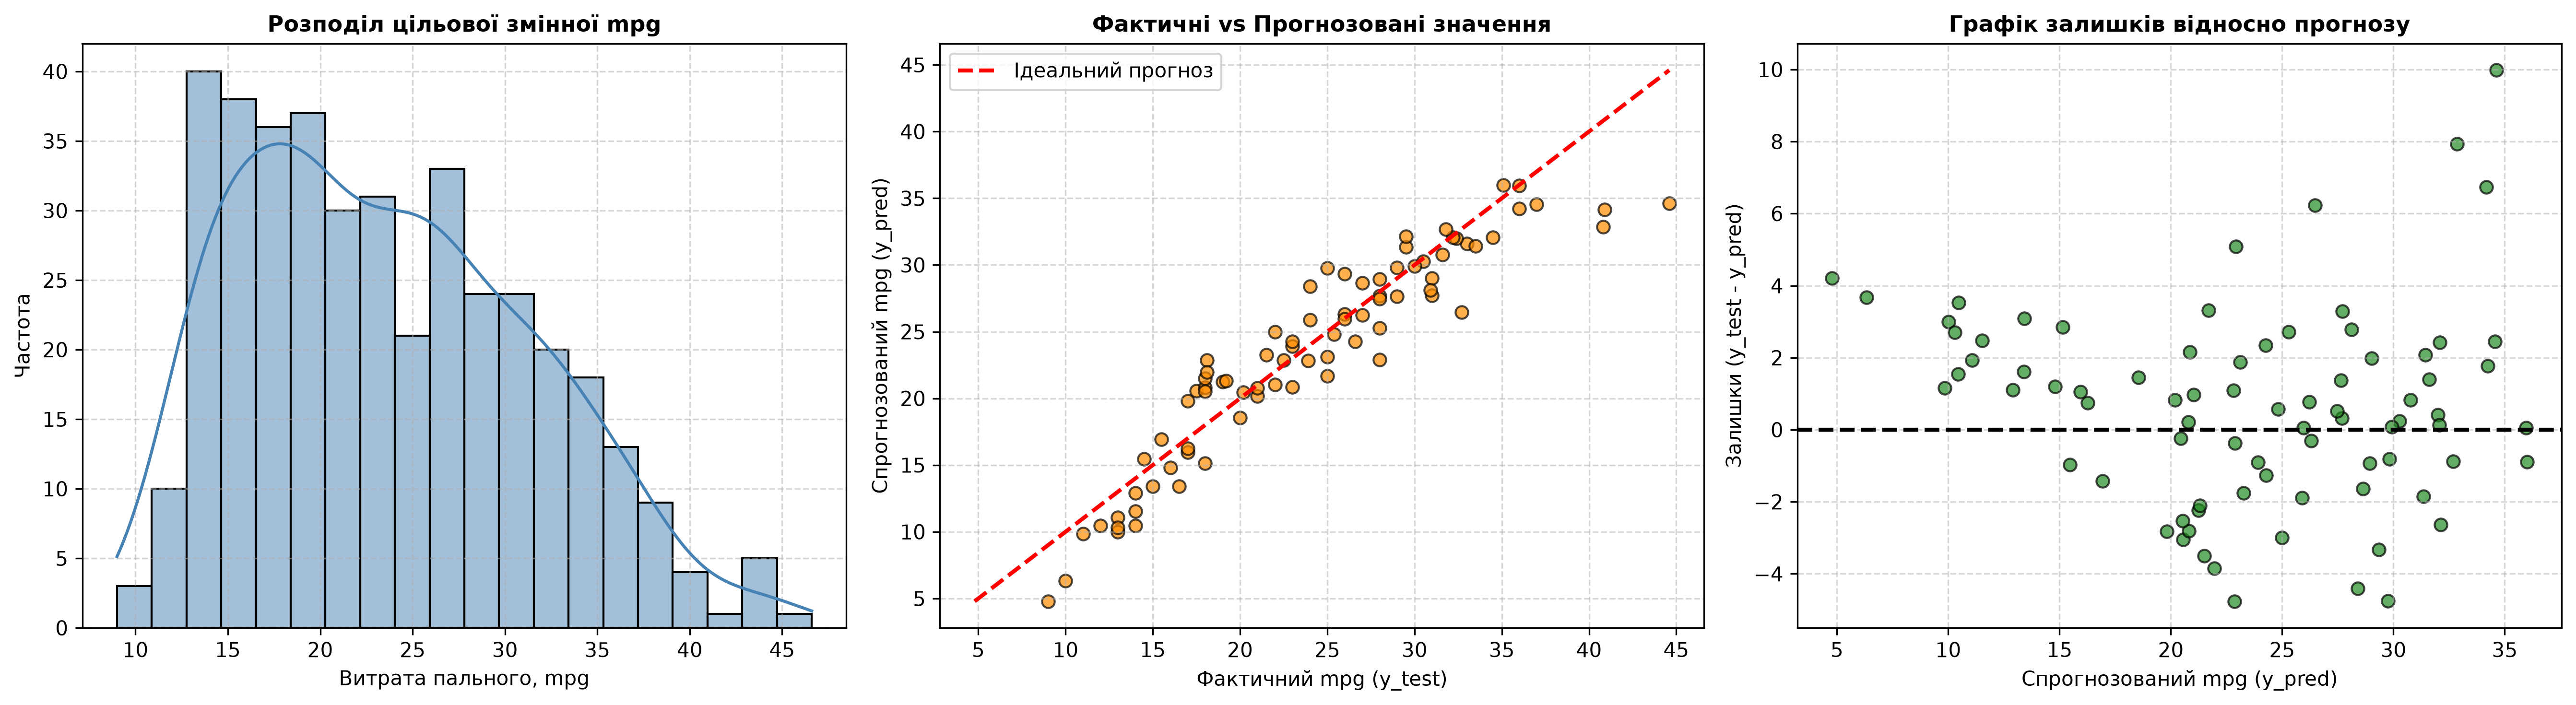

In [7]:
residuals = y_test - y_pred_lr

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=300)

# Графік 1: Розподіл цільової змінної mpg
sns.histplot(y, kde=True, ax=axes[0], color="steelblue", bins=20)
axes[0].set_title("Розподіл цільової змінної mpg", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Витрата пального, mpg", fontsize=10)
axes[0].set_ylabel("Частота", fontsize=10)
axes[0].grid(True, linestyle="--", alpha=0.5)

# Графік 2: Фактичні значення проти прогнозованих
axes[1].scatter(y_test, y_pred_lr, color="darkorange", alpha=0.7, edgecolors="k", s=40)
min_val = min(y_test.min(), y_pred_lr.min())
max_val = max(y_test.max(), y_pred_lr.max())
axes[1].plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", lw=2, label="Ідеальний прогноз")
axes[1].set_title("Фактичні vs Прогнозовані значення", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Фактичний mpg (y_test)", fontsize=10)
axes[1].set_ylabel("Спрогнозований mpg (y_pred)", fontsize=10)
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.5)

# Графік 3: Залишки відносно прогнозу
axes[2].scatter(y_pred_lr, residuals, color="forestgreen", alpha=0.7, edgecolors="k", s=40)
axes[2].axhline(0, color="black", linestyle="--", lw=2)
axes[2].set_title("Графік залишків відносно прогнозу", fontsize=11, fontweight="bold")
axes[2].set_xlabel("Спрогнозований mpg (y_pred)", fontsize=10)
axes[2].set_ylabel("Залишки (y_test - y_pred)", fontsize=10)
axes[2].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
fig.savefig("Lab3_regression_analysis.png", dpi=300)
plt.show()